## Transformer Encoder for Rainfall-Runoff Modeling

### A) Model

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch import Tensor
from torch.nn.parameter import Parameter
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler
import scipy.io
import torch.utils.data as data_utils
import pandas as pd
import time, datetime
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from scipy.io import savemat
import os
from numpy.lib.stride_tricks import as_strided
from scipy.stats import t
from pathlib import Path
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings(action='ignore')

def mc_dropout_predict(model, input_data, num_samples=50):
    model.train()  # Enable dropout layers
    predictions = []
    
    for _ in range(num_samples):
        with torch.no_grad():
            output_prediction = model(input_data)
            output_prediction = output_prediction[0,:,0]
            predictions.append(output_prediction.detach())
            
    predictions = torch.stack(predictions)
    mean_prediction = predictions.mean(dim=0)
    uncertainty = predictions.var(dim=0)
    
    return mean_prediction, uncertainty

#--------------------------------#
#          B) model              #
#--------------------------------#
  

class LSTM(nn.Module):

    def __init__(self, output_size, input_size, hidden_size, num_layers,
                 drop_out, spinup):
        super(LSTM, self).__init__()

        self.output_size = output_size
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.drop_out = drop_out

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            dropout=drop_out)

        self.fc = nn.Linear(hidden_size, output_size)

        self.spinup = spinup

    def forward(self, x):
        h_0 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_size))

        c_0 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_size))



        # Propagate input through LSTM
        h_out, (_, _) = self.lstm(x, (h_0, c_0))

        # h_out = h_out.view(-1, self.hidden_size)

        out = self.fc(h_out)
        out = out[:, spinup:out.shape[1], :]
        return out
    
def minmaxnorm(dat):
    dat[:,0] = np.log(np.sqrt(dat[:,0]) + 0.1)
    y, x1, x2 = dat[:,0], dat[:,1], dat[:,2]
    ymin = np.nanmin(y)
    y=y-ymin
    ymax=np.nanmax(y)
    y=y/ymax
    dat[:,0] = y
    return dat

def accuracy_matrix(y_obs, y_pred):
    """
    Calculates a set of hydrological model accuracy metrics.
    
    Ported from a MATLAB function.
    
    Args:
        y_obs (array-like): Observed (true) values.
        y_pred (array-like): Predicted (simulated) values.
        
    Returns:
        list: A list containing [KGE, NSE, FHV, FLV].
              KGE: Kling-Gupta Efficiency
              NSE: Nash-Sutcliffe Efficiency
              FHV: Top 2% Peak Flow Bias
              FLV: Bottom 30% Low Flow Bias
    """
    
    # Ensure inputs are 1D numpy arrays
    y_obs = np.asarray(y_obs).flatten()
    y_pred = np.asarray(y_pred).flatten()
    
    # Remove NaN values (if any)
    valid_idx = ~np.isnan(y_obs) & ~np.isnan(y_pred)
    y_obs = y_obs[valid_idx]
    y_pred = y_pred[valid_idx]
    
    # --- Calculate KGE (Gupta et al., 2009) ---
    # r (correlation)
    r, _ = pearsonr(y_pred, y_obs)
    
    # beta (bias ratio)
    beta = np.mean(y_pred) / np.mean(y_obs)
    
    # alpha (variability ratio)
    # ddof=1 for sample standard deviation, matching MATLAB's std()
    alpha = np.std(y_pred, ddof=1) / np.std(y_obs, ddof=1)
    
    # KGE calculation
    KGE = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    
    # --- Calculate NSE (Nash-Sutcliffe Efficiency) ---
    numerator = np.sum((y_pred - y_obs)**2)
    denominator = np.sum((y_obs - np.mean(y_obs))**2)
    NSE = 1 - (numerator / denominator)
    
    # --- Calculate FHV (Top 2% Peak Flow Bias, Yilmaz et al., 2008) ---
    threshold_FHV = np.percentile(y_obs, 98) # 98th percentile of observed data
    
    # Find values above or equal to the threshold
    peak_obs = y_obs[y_obs >= threshold_FHV]
    peak_pred = y_pred[y_obs >= threshold_FHV]
    
    # Calculate bias
    # Use np.sum to handle potential empty arrays (returns 0)
    FHV = 100 * (np.sum(peak_pred - peak_obs) / np.sum(peak_obs))
    
    # --- Calculate FLV (Bottom 30% Low Flow Bias, Yilmaz et al., 2008) ---
    threshold_FLV = np.percentile(y_obs, 30) # 30th percentile of observed data
    
    # Find values below or equal to the threshold
    low_obs = y_obs[y_obs <= threshold_FLV]
    low_pred = y_pred[y_obs <= threshold_FLV]
    
    # Calculate bias
    FLV = 100 * (np.sum(low_pred - low_obs) / np.sum(low_obs))
    
    data = [KGE, NSE, FHV, FLV]
    
    return data

### B) Load Data

In [13]:
dat_original  = scipy.io.loadmat('dataset/data_nonkarst.mat')['data']
dat = dat_original[4,:,-1,:] # select a target basin ex) rock creek
dat = minmaxnorm(dat)  # normalize the y value

num = dat.shape[0]
y, x1, x2 = dat[:,0], dat[:,1], dat[:,2]

train_size = round(4749*0.75)
vald_size = round(4749*0.25) 
test_size = num - train_size - vald_size

spinup = 0
dataX = Variable(torch.Tensor(np.array([dat[:, [1,2]]])))
dataY = Variable(torch.Tensor(np.array([dat[spinup:len(dat), [0]]])))

trainX = Variable(torch.Tensor(np.array([dat[0:train_size+vald_size, [1,2]]])))
trainY = Variable(torch.Tensor(np.array([dat[0:train_size+vald_size, [0]]])))

valdX = Variable(torch.Tensor(np.array([dat[spinup+train_size:train_size+vald_size, [1,2]]])))
valdY = Variable(torch.Tensor(np.array([dat[spinup+train_size:train_size+vald_size, [0]]])))

testX = Variable(torch.Tensor(np.array([dat[spinup+train_size+vald_size:num, [1,2]]])))
testY = Variable(torch.Tensor(np.array([dat[spinup+train_size+vald_size:num, [0]]])))

### C) Finetuning

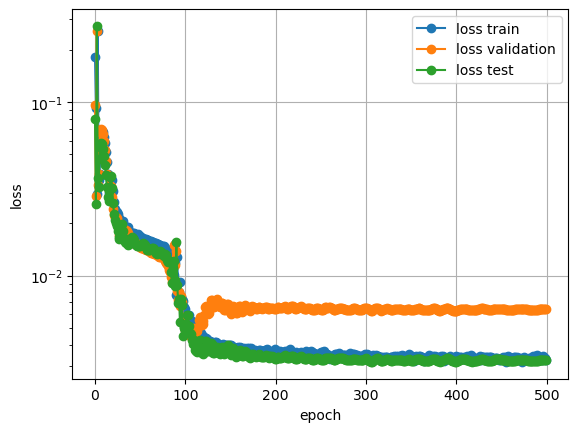

In [26]:
# hyperparameters
output_size = 1
input_size = 2

cfg = {
    'learning_rate': 0.005,
    'hidden_size': [60],   # max size sequence
    'num_layers': [4],  # mini-batch size 
    'dropout' : [0.1],
    'numEpoch': 500
    }
spinup = 0
for hidden_size in cfg['hidden_size']:
    for num_layers in cfg['num_layers']:               
        for dropout in cfg['dropout']:

            torch.manual_seed(2234)
            best_model_params_path = 'LSTM.pth'
            myModel = LSTM(output_size, input_size, hidden_size, num_layers, dropout, spinup) 
            criterion = torch.nn.MSELoss()  # mean-squared error for regression
            optimizer = torch.optim.Adam(myModel.parameters(), lr=cfg['learning_rate'])
            scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

            ############################################
            #              training!                   #
            ############################################

            t0 = time.time()
            df_train = pd.DataFrame(columns=('epoch', 'loss_train', 'loss_vald', 'loss_test'))


            for epoch in range(cfg['numEpoch']):

                # a new epoch begins
                running_loss = []

                # C.1) training set
                myModel.train()             # 'unfreeze' the parameters 
                #for batch_num, (X_train, Y_train) in enumerate(train_loader):
                    # loss
                optimizer.zero_grad()
                score = myModel(trainX)
                loss = criterion(score, trainY) #criterion(score[:,-1], Y_train[:,-1].unsqueeze(1).to(device))
                # one step optimizer
                loss.backward()
                optimizer.step()
                # estimate the loss
                running_loss.append(loss.item())

                # C.2) validation set
                myModel.eval()             # 'freeze' the parameters
                vald_loss = []
                test_loss = []
                with torch.no_grad():
                    
                    score = myModel(valdX) 
                    loss = criterion(score, valdY)
                    vald_loss.append(loss.item())

                    score = myModel(testX) 
                    loss = criterion(score, testY)
                    test_loss.append(loss.item())

                # C.3) statistics for this epoch
                epoch_train_loss = np.mean(running_loss)
                epoch_vald_loss = np.mean(vald_loss)
                epoch_test_loss = np.mean(test_loss)

                #scheduler.step()
                if epoch != 0:
                    if epoch % 10 == 0:
                        scheduler.step()

                # save
                df_train.loc[epoch] = [epoch, epoch_train_loss, epoch_vald_loss, epoch_test_loss]

            torch.save(myModel.state_dict(), best_model_params_path)     
            tFinal = time.time()
            # loss plot
            plt.figure(1);plt.clf()
            plt.plot(df_train['epoch'],df_train['loss_train'],'-o',label='loss train')  
            plt.plot(df_train['epoch'],df_train['loss_vald'],'-o',label='loss validation')
            plt.plot(df_train['epoch'],df_train['loss_test'],'-o',label='loss test')
            plt.yscale('log')
            plt.xlabel(r'epoch')
            plt.ylabel(r'loss')
            plt.legend()
            plt.grid(axis='both')
            plt.show()

### D) Retraining

In [28]:
# --------------optimized hyperparameters
hidden_size = 40
num_layers = 4
dropout = 0.1

# --------------load data
train_size = 4749
test_size = num - train_size 

dataX = Variable(torch.Tensor(np.array([dat[:, [1,2]]])))
dataY = Variable(torch.Tensor(np.array([dat[spinup:len(dat), [0]]])))

trainX = Variable(torch.Tensor(np.array([dat[0:train_size, [1,2]]])))
trainY = Variable(torch.Tensor(np.array([dat[0:train_size, [0]]])))
testX = Variable(torch.Tensor(np.array([dat[spinup+train_size:num, [1,2]]])))
testY = Variable(torch.Tensor(np.array([dat[spinup+train_size:num, [0]]])))

torch.manual_seed(2234)
best_model_params_path = 'LSTM_final.pth'
myModel = LSTM(1, 2, int(hidden_size), num_layers, dropout, spinup) 
criterion = torch.nn.MSELoss() 
optimizer = torch.optim.Adam(myModel.parameters(), lr=cfg['learning_rate'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)


# --------------training
t0 = time.time()

for epoch in range(cfg['numEpoch']):

    # a new epoch begins
    running_loss = []

    # C.1) training set
    myModel.train()            

    # loss
    optimizer.zero_grad()
    score = myModel(trainX)
    loss = criterion(score, trainY) 
    # one step optimizer
    loss.backward()
    optimizer.step()
    # estimate the loss
    running_loss.append(loss.item())

    # C.2) validation set
    myModel.eval()          
    test_loss = []
    with torch.no_grad():
        score = myModel(testX) 
        loss = criterion(score, testY) 
        # loss
        test_loss.append(loss.item())

    # C.3) statistics for this epoch
    # normalize
    epoch_train_loss = np.nanmean(running_loss)
    epoch_test_loss = np.nanmean(test_loss)

    #scheduler.step()
    if epoch != 0:
        if epoch % 10 == 0:
            scheduler.step()

torch.save(myModel.state_dict(), best_model_params_path) 

y_pred, y_var = mc_dropout_predict(myModel, dataX, num_samples=40)

# accuracy matrix
kge, nse, fhv, flv = accuracy_matrix(testY.squeeze(0).squeeze(1),y_pred[train_size:num])

print(f"Result --- NSE: {nse:.4f} KGE: {kge:.4f}")

Result --- NSE: 0.9133 KGE: 0.9137
